<a href="https://colab.research.google.com/github/bermudezfc/CCADMACL_FINAL_PROJ/blob/main/Baseline_Kmeans_Advanced_ML_Finals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd

In [25]:
df = pd.read_csv("https://raw.githubusercontent.com/bermudezfc/CCADMACL_FINAL_PROJ/refs/heads/main/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")


In [26]:
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0


In [27]:
min_value = df['Age'].min()
max_value = df['Age'].max()
print(min_value)
print(max_value)

1.0
13.0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

0 = no diabetes 1 = diabetes & prediabetes

In [29]:
df['Diabetes_binary'].value_counts()

,count
Diabetes_binary,
0.0,35346
1.0,35346


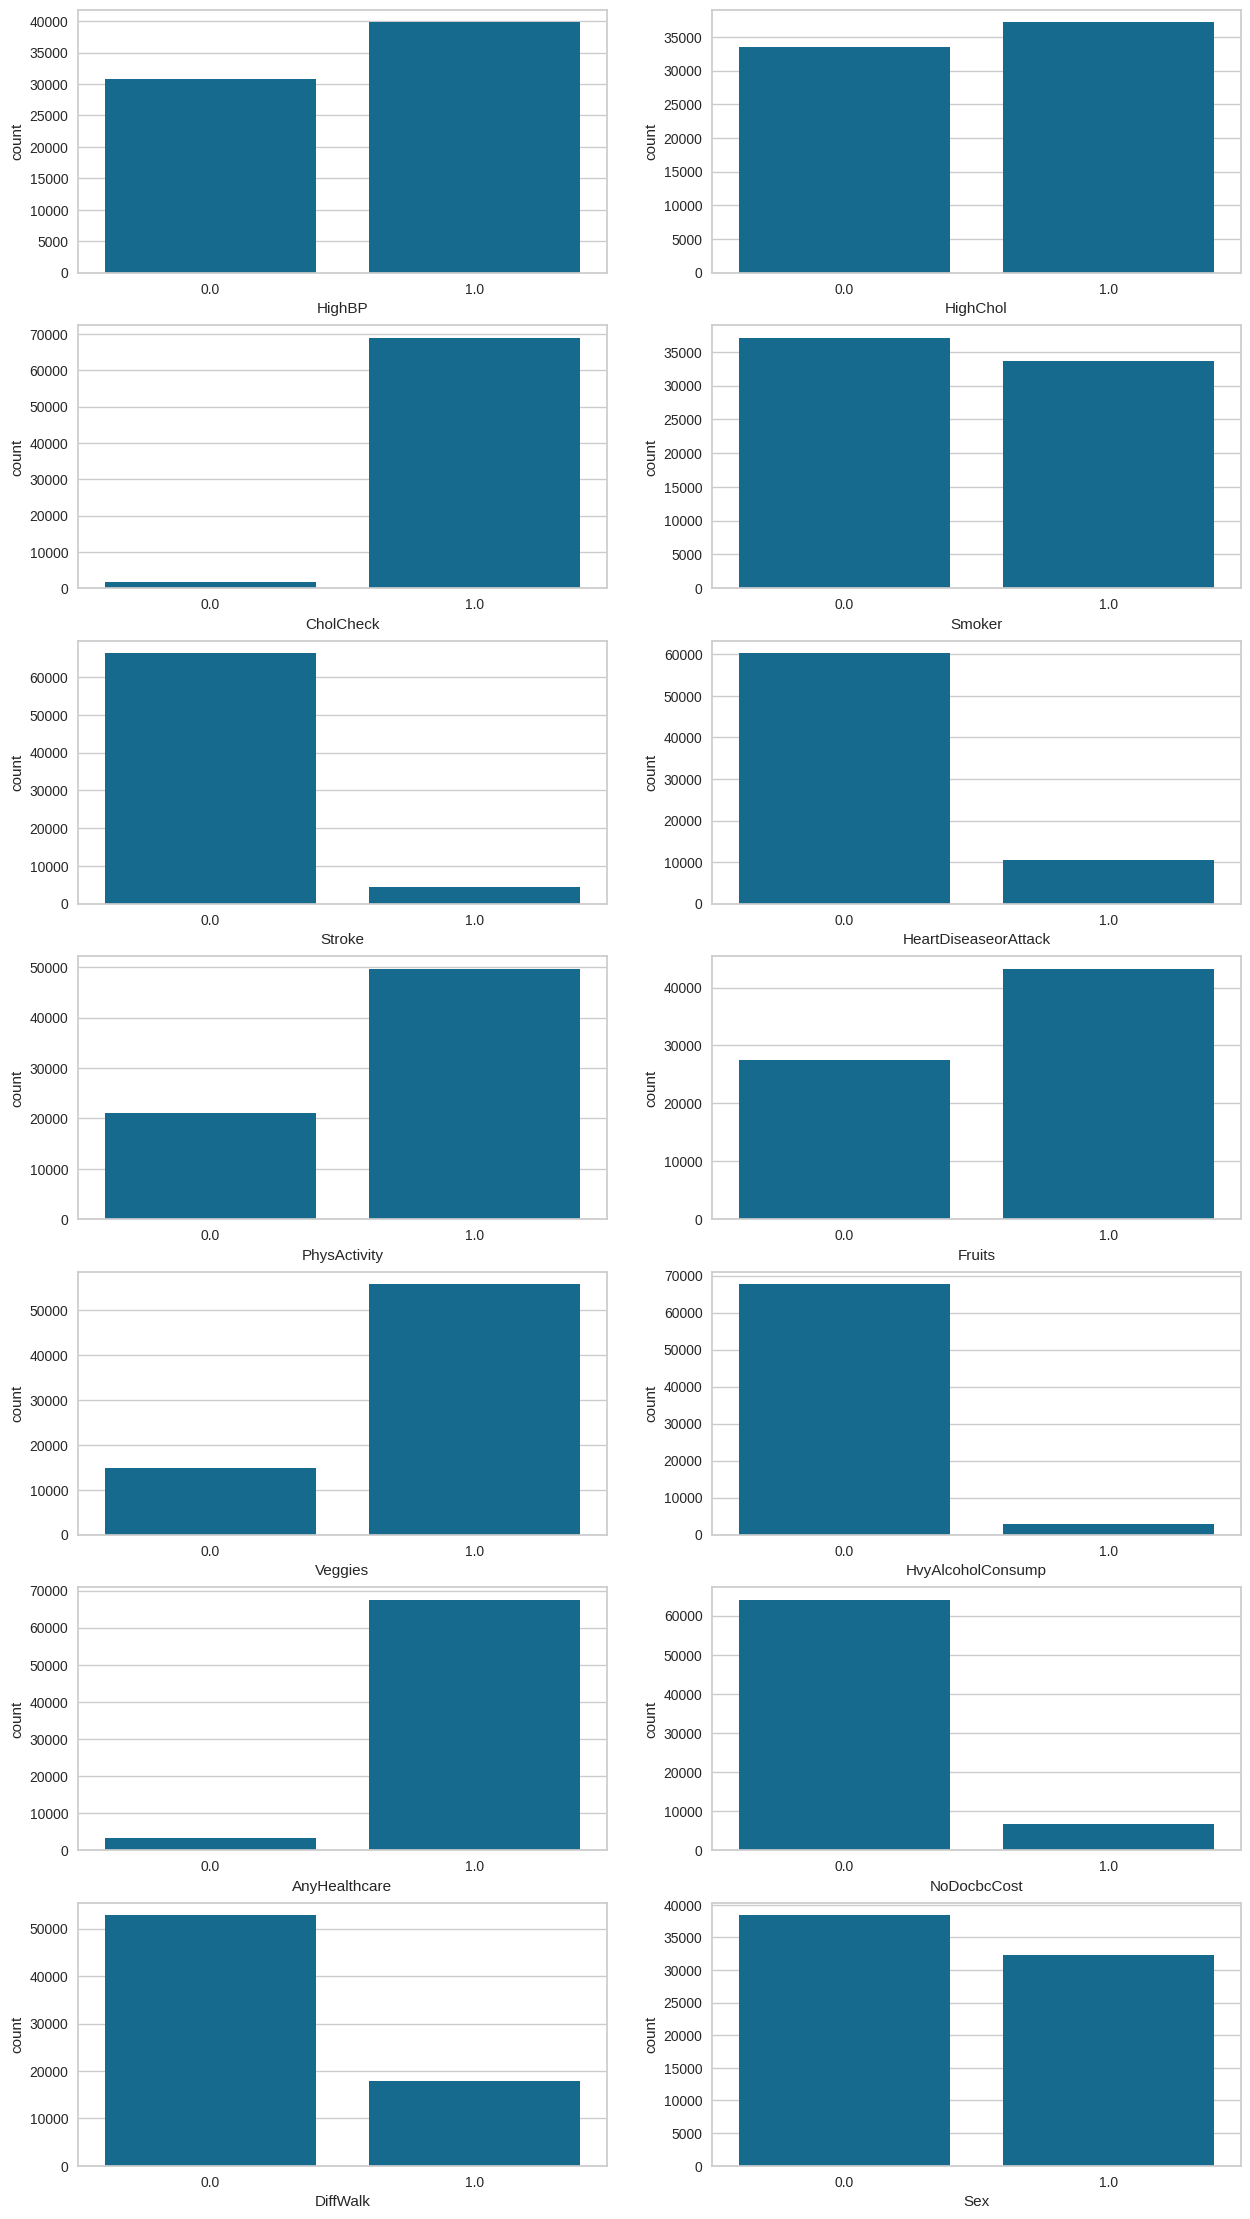

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt # Import matplotlib.pyplot
default_color = sns.color_palette()[0]

vars_to_plot = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
                'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

count = len(vars_to_plot)
cols = 2
rows = int(count/cols)
fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(15,28))
plot_no = 0

for i in range(rows):
    for j in range(cols):
        sns.countplot(data=df, x=vars_to_plot[plot_no], color=default_color, ax=ax[i][j])
        plot_no+=1

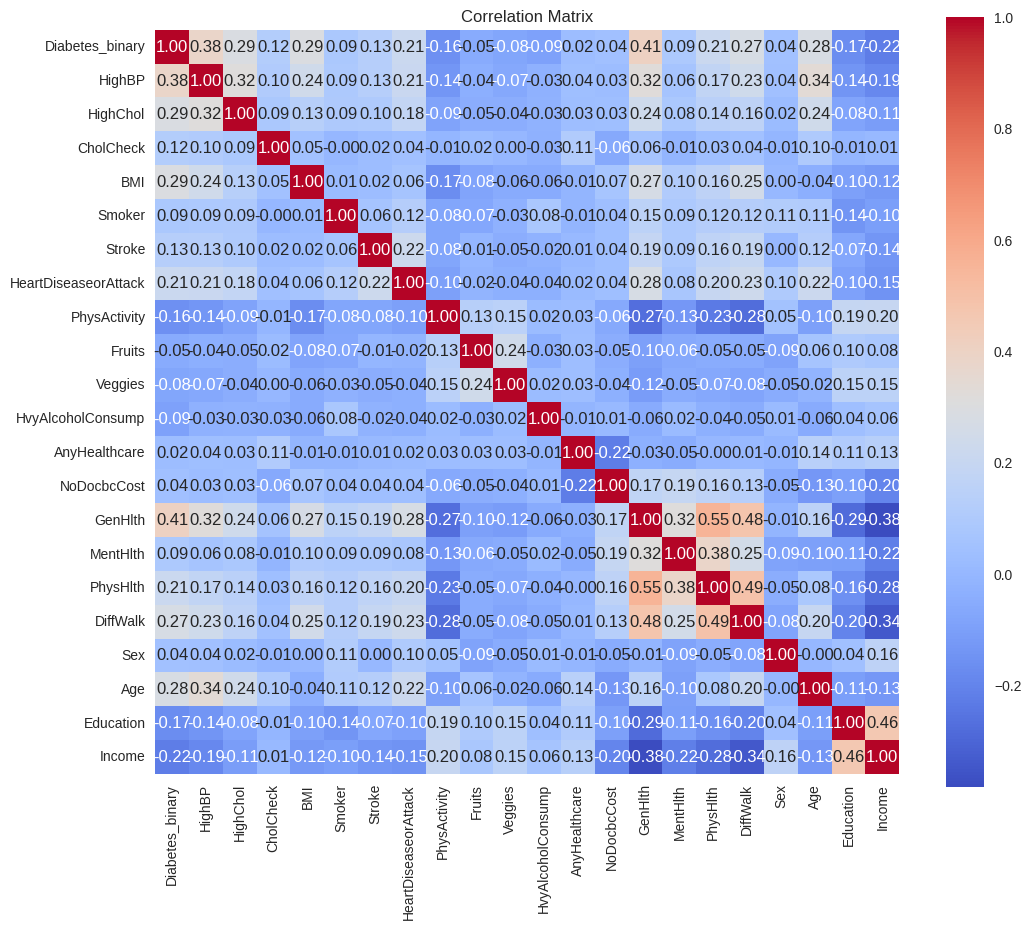

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix using pandas
corr_matrix = df.corr()

# Plot the correlation matrix using seaborn
plt.figure(figsize=(12, 10))  # Adjust figure size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix')
plt.show()

Scaling

In [32]:
# from sklearn.discriminant_analysis import StandardScaler

# ds = df.copy()
# scaler = StandardScaler()
# scaler.fit(ds)
# scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )

In [33]:
# from sklearn.preprocessing import MinMaxScaler

# ds = df.copy()
# scaler = MinMaxScaler()
# scaler.fit(ds)
# scaled_ds = pd.DataFrame(scaler.transform(ds), columns=ds.columns)


In [34]:
scaled_ds = df.copy()

PCA

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(["col1","col2", "col3"]))
PCA_ds.describe()

,col1,col2,col3
count,7.069200e+04,7.069200e+04,7.069200e+04
mean,-2.058495e-15,-1.338022e-15,-6.426365e-15
std,1.109166e+01,6.996464e+00,6.913769e+00
min,-1.014033e+01,-5.055454e+01,-2.475604e+01
25%,-7.144578e+00,-3.589522e+00,-3.778810e+00
50%,-5.450133e+00,1.196235e-01,-6.983018e-01
75%,2.651607e+00,3.130670e+00,3.271762e+00
max,4.592834e+01,2.935989e+01,6.204154e+01


In [36]:
explained_variance = pca.explained_variance_ratio_

PC1_explainedvariance = explained_variance[0]
print("Explained variance of PC1", PC1_explainedvariance)

PC2_explainedvariance = explained_variance[1]
print("Explained variance of PC2", PC2_explainedvariance)

PC3_explainedvariance = explained_variance[2]
print("Explained variance of PC3", PC3_explainedvariance)

Explained variance of PC1 0.5213828422899722
Explained variance of PC2 0.2074534677253206
Explained variance of PC3 0.20257844650264661


Explained variance of PC1 0.5213828422899722
Explained variance of PC2 0.2074534677253206
Explained variance of PC2 0.20257844650264661


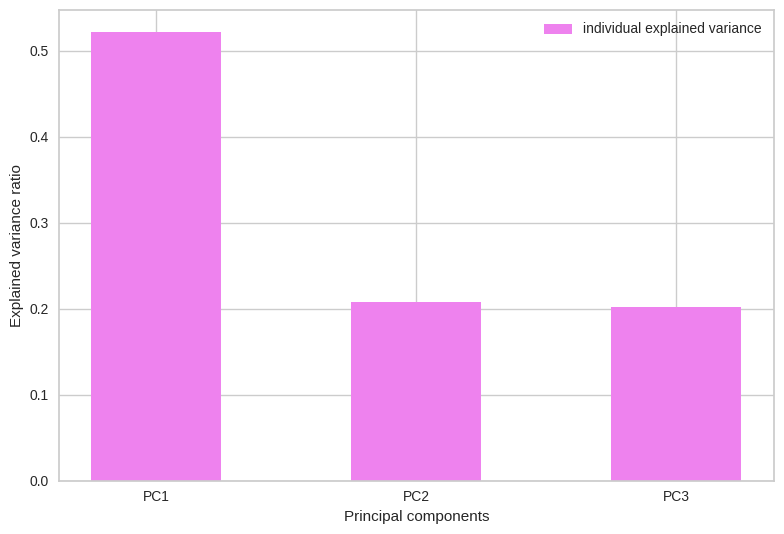

                           PC1       PC2       PC3
Diabetes_binary       0.118057 -0.106787  0.064581
HighBP                0.094607 -0.090850  0.049353
HighChol              0.079504 -0.039824  0.024999
CholCheck             0.004432 -0.008521  0.000486
BMI                   2.005567 -4.516203  5.116909
Smoker                0.065020  0.008632 -0.009565
Stroke                0.039637 -0.002752 -0.010085
HeartDiseaseorAttack  0.067840 -0.022020 -0.016074
PhysActivity         -0.115305  0.046261 -0.023591
Fruits               -0.034870  0.011191 -0.034908
Veggies              -0.032707  0.008852 -0.012460
HvyAlcoholConsump    -0.006127  0.013577 -0.002075
AnyHealthcare        -0.004964 -0.006933 -0.008690
NoDocbcCost           0.059081  0.016514  0.019121
GenHlth               0.647908 -0.157594  0.028292
MentHlth              5.481386  4.971181  3.423675
PhysHlth              9.374900 -1.918247 -3.103712
DiffWalk              0.218666 -0.066529  0.005264
Sex                  -0.034787 

In [37]:
# put your answer here
import matplotlib.pyplot as plt
import numpy as np
explained_variance = pca.explained_variance_ratio_

PC1_explainedvariance = explained_variance[0]
print("Explained variance of PC1", PC1_explainedvariance)

PC2_explainedvariance = explained_variance[1]
print("Explained variance of PC2", PC2_explainedvariance)

PC2_explainedvariance = explained_variance[2]
print("Explained variance of PC2", PC3_explainedvariance)
plt.figure()
principalcomponents = ['PC1', 'PC2', 'PC3']

plt.bar(principalcomponents, explained_variance, width=0.5, label='individual explained variance', color='violet')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout()

plt.show()
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loading_matrix = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3'], index=scaled_ds.columns)

print(loading_matrix)

Elbow Method to determine the number of clusters to be formed:


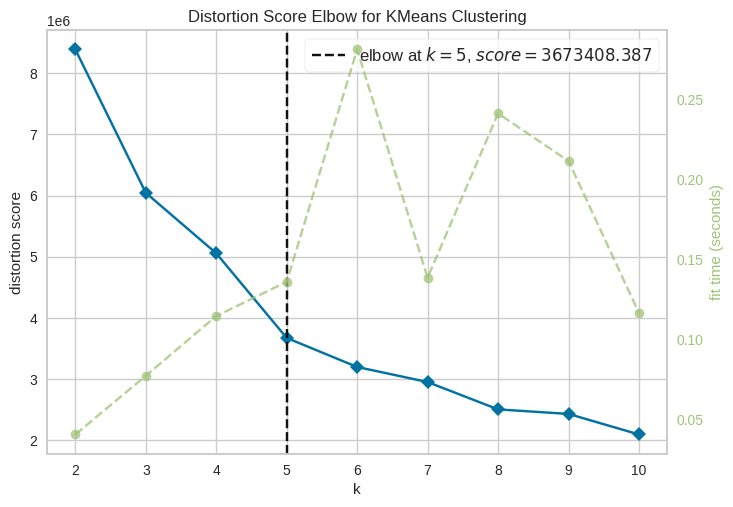

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [38]:
# put your answer here
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

pca = PCA(n_components=3)
PCA_ds = pd.DataFrame(pca.fit_transform(scaled_ds), columns=(["col1","col2", "col3"]))

print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show()

In [39]:
kmeans = KMeans(n_clusters = 5, random_state = 0, n_init='auto')
kmeans.fit(PCA_ds)
labels = kmeans.labels_
kmeans.inertia_

3673416.168125137

In [40]:
PCA_ds["Cluster"] = labels

In [41]:
kmeans= KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(PCA_ds)
PCA_ds["Clusters"]= y_kmeans
df["Clusters"]= y_kmeans

In [42]:
from sklearn.metrics import silhouette_score

score = silhouette_score(PCA_ds[['col1', 'col2', 'col3']], PCA_ds['Clusters'])
print(f"Silhouette Score: {score}")


Silhouette Score: 0.46676473219564046


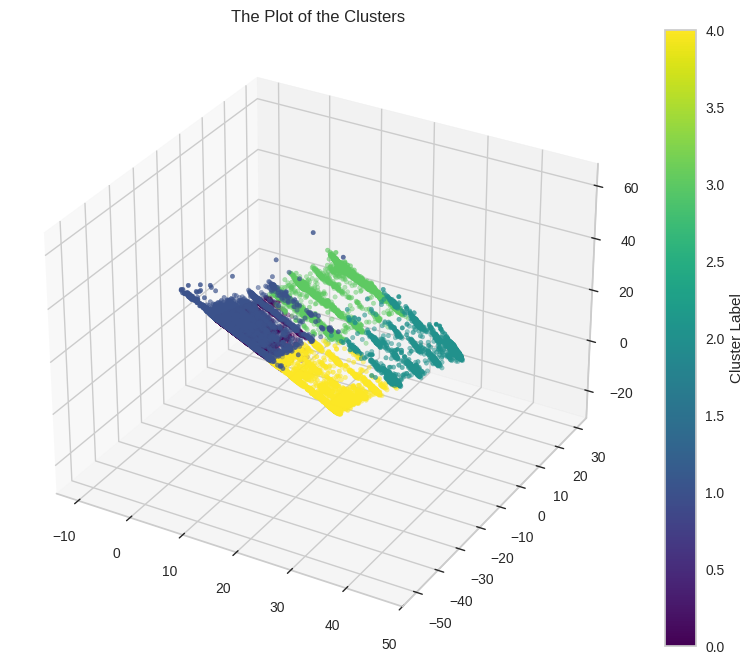

In [43]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

x = PCA_ds["col1"]
y = PCA_ds["col2"]
z = PCA_ds["col3"]


cmap = plt.get_cmap("viridis")

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x, y, z, s=10, c=PCA_ds["Clusters"], marker='o', cmap=cmap)

plt.colorbar(scatter, label="Cluster Label")

ax.set_title("The Plot of the Clusters")
plt.show()

Interactive Plot

In [22]:
import plotly.express as px

fig = px.scatter_3d(
    PCA_ds, x="col1", y="col2", z="col3",
    color="Clusters", size_max=10, opacity=0.8
)

fig.update_layout(title="Interactive 3D Clustering Visualization")
fig.show()


<ipython-input-44-752ecc45e345>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-44-752ecc45e345>:3: UserWarning:


The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.



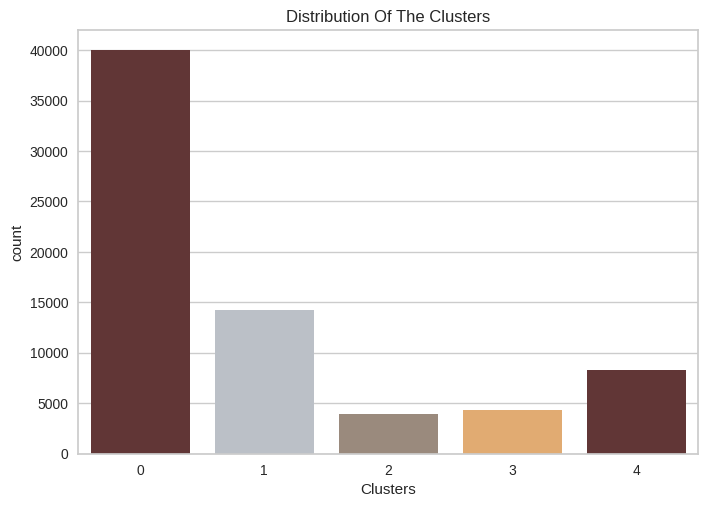

In [44]:
import seaborn as sns
pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60"]
pl = sns.countplot(x=df["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()